# Week 6: Feature Engineering

## California Property Price Prediction

This notebook evaluates whether engineered real-estate features improve
property price predictions.

The workflow includes:

1. Loading the Week 5 processed datasets
2. Creating new property-related features
3. Training the best Week 5 model on the original features
4. Training the same model on the engineered features
5. Comparing MAE, RMSE, MAPE, MdAPE, and R²
6. Saving the new datasets, model, metrics, and visualizations

The target variable, `ClosePrice`, is not used to construct any new
predictor feature.

In [2]:
from pathlib import Path
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

In [3]:
# This notebook is expected to run from the notebooks/ directory.

PROJECT_ROOT = Path.cwd().parent

# Handle the case where Jupyter starts in the project root instead.
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
SRC_DIR = PROJECT_ROOT / "src"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")
print(f"Reports directory: {REPORTS_DIR}")

Project root: C:\Users\sonng\California_Housing_Data
Data directory: C:\Users\sonng\California_Housing_Data\data
Models directory: C:\Users\sonng\California_Housing_Data\models
Reports directory: C:\Users\sonng\California_Housing_Data\reports


In [4]:
from features import (
    align_datasets,
    create_features,
    fill_engineered_missing_values,
    validate_output,
)

print("Feature-engineering functions imported successfully.")

Feature-engineering functions imported successfully.


In [5]:
train_file = DATA_DIR / "train_processed.csv"
test_file = DATA_DIR / "test_processed.csv"

if not train_file.exists():
    raise FileNotFoundError(
        f"Training data was not found at: {train_file}"
    )

if not test_file.exists():
    raise FileNotFoundError(
        f"Testing data was not found at: {test_file}"
    )

train_original = pd.read_csv(train_file)
test_original = pd.read_csv(test_file)

print(f"Original training shape: {train_original.shape}")
print(f"Original testing shape: {test_original.shape}")

train_original.head()

Original training shape: (49703, 975)
Original testing shape: (12024, 975)


,LotSizeSquareFeet,LivingArea,BathroomsTotalInteger,ClosePrice,BedroomsTotal,ListPrice,PropertyAge,City_Acampo,City_Acton,City_Adelanto,City_Agoura Hills,City_Agua Dulce,City_Aguanga,City_Ahwahnee,City_Alameda,City_Alamo,City_Albany,City_Albion,City_Alhambra,City_Aliso Viejo,City_Almanor,City_Alpine,City_Alta Loma,City_Altadena,City_Alturas,City_Alviso,City_American Canyon,City_Anaheim,City_Anaheim Hills,City_Anderson,City_Angels Camp,City_Angelus Oaks,City_Angwin,City_Antelope,City_Antioch,City_Anza,City_Apple Valley,City_Aptos,City_Arbuckle,City_Arcadia,City_Arleta,City_Arnold,City_Aromas,City_Arrowbear,City_Arroyo Grande,City_Artesia,City_Artois,City_Arvin,City_Atascadero,City_Atherton,City_Atwater,City_Atwater Village,City_Auberry,City_Auburn,City_Avalon,City_Avenal,City_Avila Beach,City_Azusa,City_Bakersfield,City_Baldwin Hills,City_Baldwin Park,City_Bangor,City_Banning,City_Barstow,City_Bass Lake,City_Bay Point,City_Beaumont,City_Bel Air,City_Bell,City_Bell Canyon,City_Bell Gardens,City_Bellflower,City_Belmont,City_Ben Lomond,City_Benicia,City_Berkeley,City_Bermuda Dunes,City_Berry Creek,City_Bethel Island,City_Beverly Hills,City_Big Bar,City_Big Bear,City_Big Bear City,City_Big Bear Lake,City_Big River,City_Big Sur,City_Biggs,City_Bishop,City_Bloomington,City_Blue Jay,City_Blythe,City_Bodfish,City_Bombay Beach,City_Bonita,City_Bonsall,City_Boron,City_Borrego Springs,City_Boulder Creek,City_Boulevard,City_Bradbury,...,City_Weaverville,City_Weed,City_Weldon,City_West Covina,City_West Hills,City_West Hollywood,City_West Los Angeles,City_West Point,City_West Sacramento,City_West Toluca Lake,City_Westchester,City_Westlake Village,City_Westminster,City_Westport,City_Westwood,City_Wheatland,City_Whitewater,City_Whittier,City_Wildomar,City_Williams,City_Willits,City_Willows,City_Wilmington,City_Wilton,City_Winchester,City_Windsor Hills,City_Winnetka,City_Winton,City_Wishon,City_Wofford Heights,City_Woodbridge,City_Woodcrest,City_Woodland,City_Woodland Hills,City_Woodside,City_Wrightwood,City_Yermo,City_Yorba Linda,City_Yosemite,City_Yreka,City_Yuba City,City_Yucaipa,City_Yucca Valley,CountyOrParish_Amador,CountyOrParish_Butte,CountyOrParish_Calaveras,CountyOrParish_Colusa,CountyOrParish_Contra Costa,CountyOrParish_El Dorado,CountyOrParish_Foreign Country,CountyOrParish_Fresno,CountyOrParish_Glenn,CountyOrParish_Humboldt,CountyOrParish_Imperial,CountyOrParish_Inyo,CountyOrParish_Kern,CountyOrParish_Kings,CountyOrParish_Lake,CountyOrParish_Lassen,CountyOrParish_Los Angeles,CountyOrParish_Madera,CountyOrParish_Marin,CountyOrParish_Mariposa,CountyOrParish_Mendocino,CountyOrParish_Merced,CountyOrParish_Modoc,CountyOrParish_Mono,CountyOrParish_Monterey,CountyOrParish_Napa,CountyOrParish_Nevada,CountyOrParish_Orange,CountyOrParish_Other,CountyOrParish_Other State,CountyOrParish_Placer,CountyOrParish_Plumas,CountyOrParish_Riverside,CountyOrParish_Sacramento,CountyOrParish_San Benito,CountyOrParish_San Bernardino,CountyOrParish_San Diego,CountyOrParish_San Francisco,CountyOrParish_San Joaquin,CountyOrParish_San Luis Obispo,CountyOrParish_San Mateo,CountyOrParish_Santa Barbara,CountyOrParish_Santa Clara,CountyOrParish_Santa Cruz,CountyOrParish_Shasta,CountyOrParish_Siskiyou,CountyOrParish_Solano,CountyOrParish_Sonoma,CountyOrParish_Stanislaus,CountyOrParish_Sutter,CountyOrParish_Tehama,CountyOrParish_Trinity,CountyOrParish_Tulare,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba
0,"10,080.0000","2,045.0000",2.0000,"1,998,000.0000",4.0000,"1,998,000.0000",57.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

In [6]:
print("Original columns:")

for column_number, column_name in enumerate(
    train_original.columns,
    start=1,
):
    print(f"{column_number:>3}. {column_name}")

Original columns:
  1. LotSizeSquareFeet
  2. LivingArea
  3. BathroomsTotalInteger
  4. ClosePrice
  5. BedroomsTotal
  6. ListPrice
  7. PropertyAge
  8. City_Acampo
  9. City_Acton
 10. City_Adelanto
 11. City_Agoura Hills
 12. City_Agua Dulce
 13. City_Aguanga
 14. City_Ahwahnee
 15. City_Alameda
 16. City_Alamo
 17. City_Albany
 18. City_Albion
 19. City_Alhambra
 20. City_Aliso Viejo
 21. City_Almanor
 22. City_Alpine
 23. City_Alta Loma
 24. City_Altadena
 25. City_Alturas
 26. City_Alviso
 27. City_American Canyon
 28. City_Anaheim
 29. City_Anaheim Hills
 30. City_Anderson
 31. City_Angels Camp
 32. City_Angelus Oaks
 33. City_Angwin
 34. City_Antelope
 35. City_Antioch
 36. City_Anza
 37. City_Apple Valley
 38. City_Aptos
 39. City_Arbuckle
 40. City_Arcadia
 41. City_Arleta
 42. City_Arnold
 43. City_Aromas
 44. City_Arrowbear
 45. City_Arroyo Grande
 46. City_Artesia
 47. City_Artois
 48. City_Arvin
 49. City_Atascadero
 50. City_Atherton
 51. City_Atwater
 52. City_Atwater

In [7]:
train_engineered = create_features(train_original)
test_engineered = create_features(test_original)

train_engineered, test_engineered = fill_engineered_missing_values(
    train_df=train_engineered,
    test_df=test_engineered,
)

train_engineered, test_engineered = align_datasets(
    train_df=train_engineered,
    test_df=test_engineered,
)

# Basic validation
print(f"Engineered training shape: {train_engineered.shape}")
print(f"Engineered testing shape: {test_engineered.shape}")

print("\nMissing values in training:",
      train_engineered.isna().sum().sum())

print("Missing values in testing:",
      test_engineered.isna().sum().sum())

print("\nTraining columns:", len(train_engineered.columns))
print("Testing columns:", len(test_engineered.columns))

assert list(train_engineered.columns) == list(test_engineered.columns), \
    "Train and test columns do not match."

print("\n✅ Feature engineering completed successfully.")

Engineered training shape: (49703, 989)
Engineered testing shape: (12024, 989)

Missing values in training: 0
Missing values in testing: 0

Training columns: 989
Testing columns: 989

✅ Feature engineering completed successfully.


In [8]:
original_columns = set(train_original.columns)
engineered_columns = set(train_engineered.columns)

new_features = sorted(
    engineered_columns - original_columns
)

print(f"Number of engineered features: {len(new_features)}")
print()

for feature_number, feature_name in enumerate(
    new_features,
    start=1,
):
    print(f"{feature_number:>2}. {feature_name}")

Number of engineered features: 14

 1. BedBathRatio
 2. IsNewProperty
 3. IsOlderProperty
 4. IsRecentProperty
 5. ListPricePerSquareFoot
 6. LivingAreaPerBathroom
 7. LivingAreaPerBedroom
 8. LogListPrice
 9. LogLivingArea
10. LogLotSize
11. LotToLivingAreaRatio
12. OutdoorSpaceApprox
13. PropertyAgeSquared
14. TotalRoomsApprox


In [9]:
feature_descriptions = pd.DataFrame(
    {
        "Feature": [
            "LivingAreaPerBedroom",
            "LivingAreaPerBathroom",
            "BedBathRatio",
            "ListPricePerSquareFoot",
            "LotToLivingAreaRatio",
            "TotalRoomsApprox",
            "OutdoorSpaceApprox",
            "LogLivingArea",
            "LogLotSize",
            "LogListPrice",
            "IsNewProperty",
            "IsRecentProperty",
            "IsOlderProperty",
            "PropertyAgeSquared",
        ],
        "Description": [
            "Living area divided by bedroom count",
            "Living area divided by bathroom count",
            "Bedroom count divided by bathroom count",
            "Listing price divided by living area",
            "Lot size divided by living area",
            "Bedrooms plus bathrooms",
            "Lot size minus living area",
            "Natural log of living area",
            "Natural log of lot size",
            "Natural log of listing price",
            "1 when property age is five years or less",
            "1 when property age is fifteen years or less",
            "1 when property age is fifty years or more",
            "Squared property age for nonlinear relationships",
        ],
    }
)

feature_descriptions

,Feature,Description
0,LivingAreaPerBedroom,Living area divided by bedroom count
1,LivingAreaPerBathroom,Living area divided by bathroom count
2,BedBathRatio,Bedroom count divided by bathroom count
3,ListPricePerSquareFoot,Listing price divided by living area
4,LotToLivingAreaRatio,Lot size divided by living area
5,TotalRoomsApprox,Bedrooms plus bathrooms
6,OutdoorSpaceApprox,Lot size minus living area
7,LogLivingArea,Natural log of living area
8,LogLotSize,Natural log of lot size
9,LogListPrice,Natural log of listing price


In [10]:
preview_columns = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "ListPrice",
    "PropertyAge",
    *new_features,
]

available_preview_columns = [
    column
    for column in preview_columns
    if column in train_engineered.columns
]

train_engineered[
    available_preview_columns
].head(10)

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,ListPrice,PropertyAge,BedBathRatio,IsNewProperty,IsOlderProperty,IsRecentProperty,ListPricePerSquareFoot,LivingAreaPerBathroom,LivingAreaPerBedroom,LogListPrice,LogLivingArea,LogLotSize,LotToLivingAreaRatio,OutdoorSpaceApprox,PropertyAgeSquared,TotalRoomsApprox
0,"1,998,000.0000","2,045.0000",4.0000,2.0000,"10,080.0000","1,998,000.0000",57.0000,2.0000,0,1,0,977.0171,"1,022.5000",511.2500,14.5077,7.6236,9.2184,4.9291,"8,035.0000","3,249.0000",6.0000
1,"2,214,421.0000","3,050.0000",4.0000,4.0000,"34,745.0000","2,214,421.0000",68.0000,1.0000,0,1,0,726.0397,762.5000,762.5000,14.6105,8.0232,10.4558,11.3918,"31,695.0000","4,624.0000",8.0000
2,"1,200,000.0000","1,594.0000",4.0000,2.0000,"6,600.0000","1,200,000.0000",47.0000,2.0000,0,0,0,752.8231,797.0000,398.5000,13.9978,7.3746,8.7950,4.1405,"5,006.0000","2,209.0000",6.0000
3,"3,100,000.0000","2,700.0000",5.0000,3.0000,"8,262.0000","3,100,000.0000",0.0000,1.6667,1,0,1,"1,148.1481",900.0000,540.0000,14.9469,7.9014,9.0195,3.0600,"5,562.0000",0.0000,8.0000
4,"2,900,000.0000","2,948.0000",5.0000,4.0000,"9,222.0000","2,900,000.0000",2.0000,1.2500,1,0,1,983.7178,737.0000,589.6000,14.8802,7.9892,9.1295,3.1282,"6,274.0000",4.0000,9.0000
5,"1,050,000.0000","1,503.0000",3.0000,2.0000,"3,478.0000","1,099,000.0000",40.0000,1.5000,0,0,0,731.2043,751.5000,501.0000,13.9099,7.3159,8.1545,2.3140,"1,975.0000","1,600.0000",5.0000
6,"705,000.0000","1,250.0000",3.0000,1.0000,"7,000.0000","699,999.0000",77.0000,3.0000,0,1,0,559.9992,"1,250.0000",416.6667,13.4588,7.1317,8.8538,5.6000,"5,750.0000","5,929.0000",4.0000
7,"1,140,000.0000","3,574.0000",5.0000,4.0000,"12,197.0000","1,140,000.0000",19.0000,1.2500,0,0,0,318.9703,893.5000,714.8000,13.9465,8.1817,9.4090,3.4127,"8,623.0000",361.0000,9.0000
8,"914,000.0000","1,656.0000",3.0000,3.0000,"3,051.0000","914,000.0000",65.0000,1.0000,0,1,0,551.9324,552.0000,552.0000,13.7256,7.4128,8.0236,1.8424,"1,395.0000","4,225.0000",6.0000
9,"2,500,000.0000","1,459.0000",3.0000,3.0000,"2,825.0000","2,500,000.0000",107.0000,1.0000,0,1,0,"1,713.5024",486.3333,486.3333,14.7318,7.2862,7.9466,1.9363,"1,366.0000","11,449.0000",6.0000


In [11]:
train_features_file = DATA_DIR / "train_features.csv"
test_features_file = DATA_DIR / "test_features.csv"

train_engineered.to_csv(
    train_features_file,
    index=False,
)

test_engineered.to_csv(
    test_features_file,
    index=False,
)

print(f"Saved: {train_features_file}")
print(f"Saved: {test_features_file}")

Saved: C:\Users\sonng\California_Housing_Data\data\train_features.csv
Saved: C:\Users\sonng\California_Housing_Data\data\test_features.csv


In [12]:
TARGET_COLUMN = "ClosePrice"

# Original features
X_train_original = train_original.drop(
    columns=[TARGET_COLUMN]
)

y_train = train_original[TARGET_COLUMN]

X_test_original = test_original.drop(
    columns=[TARGET_COLUMN]
)

y_test = test_original[TARGET_COLUMN]

X_train_original, X_test_original = X_train_original.align(
    X_test_original,
    join="left",
    axis=1,
    fill_value=0,
)

# Engineered features
X_train_engineered = train_engineered.drop(
    columns=[TARGET_COLUMN]
)

X_test_engineered = test_engineered.drop(
    columns=[TARGET_COLUMN]
)

X_train_engineered, X_test_engineered = (
    X_train_engineered.align(
        X_test_engineered,
        join="left",
        axis=1,
        fill_value=0,
    )
)

print(
    "Original feature count:",
    X_train_original.shape[1],
)

print(
    "Engineered feature count:",
    X_train_engineered.shape[1],
)

print(f"Training observations: {len(y_train):,}")
print(f"Testing observations: {len(y_test):,}")

Original feature count: 974
Engineered feature count: 988
Training observations: 49,703
Testing observations: 12,024


In [13]:
comparison_file = REPORTS_DIR / "comparison_metrics.csv"

if comparison_file.exists():
    week5_comparison = pd.read_csv(comparison_file)

    week5_comparison = week5_comparison.sort_values(
        by="R2",
        ascending=False,
    ).reset_index(drop=True)

    print("Week 5 model comparison:")
    display(week5_comparison)

    best_model_name = week5_comparison.loc[0, "Model"]

else:
    print(
        "Week 5 comparison metrics were not found. "
        "Random Forest will be used as the default model."
    )

    best_model_name = "Random Forest"

print(f"Selected Week 5 model: {best_model_name}")

Week 5 model comparison:


,Model,MAE,RMSE,MAPE,R2
0,Decision Tree,"97,711.9871","1,011,477.0948",8.9738,0.6367
1,Linear Regression,"185,741.8081","1,158,377.4918",22.2336,0.5235
2,Random Forest,"104,269.1508","1,711,896.5111",10.9237,-0.0407
3,Gradient Boosting,"223,104.6432","4,144,731.6931",30.3870,-5.1007


Selected Week 5 model: Decision Tree


In [14]:
def create_model(model_name):
    """
    Create a new model using the Week 5 model name.
    """

    model_options = {
        "Linear Regression": LinearRegression(),

        "Decision Tree": DecisionTreeRegressor(
            random_state=42,
        ),

        "Random Forest": RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
        ),

        "Gradient Boosting": GradientBoostingRegressor(
            random_state=42,
        ),
    }

    if model_name not in model_options:
        print(
            f"Model '{model_name}' is not recognized. "
            "Random Forest will be used."
        )

        return RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
        )

    return model_options[model_name]

In [15]:
def calculate_mape(actual, predicted):
    """
    Calculate Mean Absolute Percentage Error.
    """

    actual_array = np.asarray(actual)
    predicted_array = np.asarray(predicted)

    non_zero_mask = actual_array != 0

    if not np.any(non_zero_mask):
        return np.nan

    percentage_errors = np.abs(
        (
            actual_array[non_zero_mask]
            - predicted_array[non_zero_mask]
        )
        / actual_array[non_zero_mask]
    )

    return float(
        np.mean(percentage_errors) * 100
    )


def calculate_mdape(actual, predicted):
    """
    Calculate Median Absolute Percentage Error.
    """

    actual_array = np.asarray(actual)
    predicted_array = np.asarray(predicted)

    non_zero_mask = actual_array != 0

    if not np.any(non_zero_mask):
        return np.nan

    percentage_errors = np.abs(
        (
            actual_array[non_zero_mask]
            - predicted_array[non_zero_mask]
        )
        / actual_array[non_zero_mask]
    )

    return float(
        np.median(percentage_errors) * 100
    )


def evaluate_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
):
    """
    Train a model and return its predictions and metrics.
    """

    model.fit(
        X_train,
        y_train,
    )

    predictions = model.predict(X_test)

    metrics = {
        "MAE": float(
            mean_absolute_error(
                y_test,
                predictions,
            )
        ),

        "RMSE": float(
            np.sqrt(
                mean_squared_error(
                    y_test,
                    predictions,
                )
            )
        ),

        "MAPE": calculate_mape(
            y_test,
            predictions,
        ),

        "MdAPE": calculate_mdape(
            y_test,
            predictions,
        ),

        "R2": float(
            r2_score(
                y_test,
                predictions,
            )
        ),
    }

    return predictions, metrics

In [16]:
original_model = create_model(
    best_model_name
)

original_predictions, original_metrics = evaluate_model(
    model=original_model,
    X_train=X_train_original,
    y_train=y_train,
    X_test=X_test_original,
    y_test=y_test,
)

print("Original feature model completed.")

for metric_name, metric_value in original_metrics.items():

    if metric_name in ["MAE", "RMSE"]:
        print(
            f"{metric_name}: ${metric_value:,.2f}"
        )

    elif metric_name in ["MAPE", "MdAPE"]:
        print(
            f"{metric_name}: {metric_value:.2f}%"
        )

    else:
        print(
            f"{metric_name}: {metric_value:.4f}"
        )

Original feature model completed.
MAE: $97,711.99
RMSE: $1,011,477.09
MAPE: 8.97%
MdAPE: 3.43%
R2: 0.6367


In [17]:
engineered_model = create_model(
    best_model_name
)

engineered_predictions, engineered_metrics = evaluate_model(
    model=engineered_model,
    X_train=X_train_engineered,
    y_train=y_train,
    X_test=X_test_engineered,
    y_test=y_test,
)

print("Engineered feature model completed.")

for metric_name, metric_value in engineered_metrics.items():

    if metric_name in ["MAE", "RMSE"]:
        print(
            f"{metric_name}: ${metric_value:,.2f}"
        )

    elif metric_name in ["MAPE", "MdAPE"]:
        print(
            f"{metric_name}: {metric_value:.2f}%"
        )

    else:
        print(
            f"{metric_name}: {metric_value:.4f}"
        )

Engineered feature model completed.
MAE: $336,533.40
RMSE: $13,306,845.40
MAPE: 30.32%
MdAPE: 3.49%
R2: -61.8833


In [18]:
feature_comparison = pd.DataFrame(
    [
        {
            "FeatureSet": "Original Features",
            "Model": best_model_name,
            **original_metrics,
        },
        {
            "FeatureSet": "Engineered Features",
            "Model": best_model_name,
            **engineered_metrics,
        },
    ]
)

feature_comparison

,FeatureSet,Model,MAE,RMSE,MAPE,MdAPE,R2
0,Original Features,Decision Tree,"97,711.9871","1,011,477.0948",8.9738,3.4347,0.6367
1,Engineered Features,Decision Tree,"336,533.4000","13,306,845.4018",30.3233,3.4884,-61.8833


In [19]:
improvement_summary = pd.DataFrame(
    {
        "Metric": [
            "MAE",
            "RMSE",
            "MAPE",
            "MdAPE",
            "R2",
        ],

        "Original": [
            original_metrics["MAE"],
            original_metrics["RMSE"],
            original_metrics["MAPE"],
            original_metrics["MdAPE"],
            original_metrics["R2"],
        ],

        "Engineered": [
            engineered_metrics["MAE"],
            engineered_metrics["RMSE"],
            engineered_metrics["MAPE"],
            engineered_metrics["MdAPE"],
            engineered_metrics["R2"],
        ],
    }
)

# For error metrics, positive improvement means the error decreased.
# For R², positive improvement means the score increased.
improvement_summary["Improvement"] = [
    original_metrics["MAE"] - engineered_metrics["MAE"],
    original_metrics["RMSE"] - engineered_metrics["RMSE"],
    original_metrics["MAPE"] - engineered_metrics["MAPE"],
    original_metrics["MdAPE"] - engineered_metrics["MdAPE"],
    engineered_metrics["R2"] - original_metrics["R2"],
]

improvement_summary

,Metric,Original,Engineered,Improvement
0,MAE,"97,711.9871","336,533.4000","-238,821.4129"
1,RMSE,"1,011,477.0948","13,306,845.4018","-12,295,368.3070"
2,MAPE,8.9738,30.3233,-21.3495
3,MdAPE,3.4347,3.4884,-0.0537
4,R2,0.6367,-61.8833,-62.5200


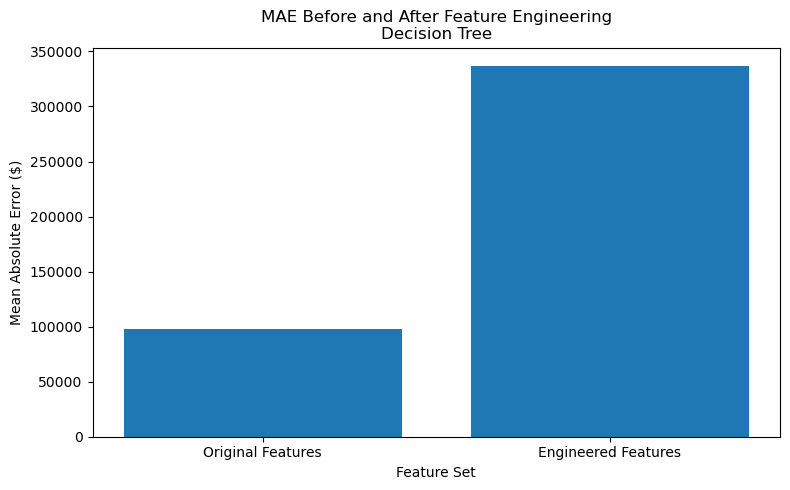

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_comparison["FeatureSet"],
    feature_comparison["MAE"],
)

plt.xlabel("Feature Set")
plt.ylabel("Mean Absolute Error ($)")
plt.title(
    f"MAE Before and After Feature Engineering\n"
    f"{best_model_name}"
)

plt.tight_layout()
plt.show()

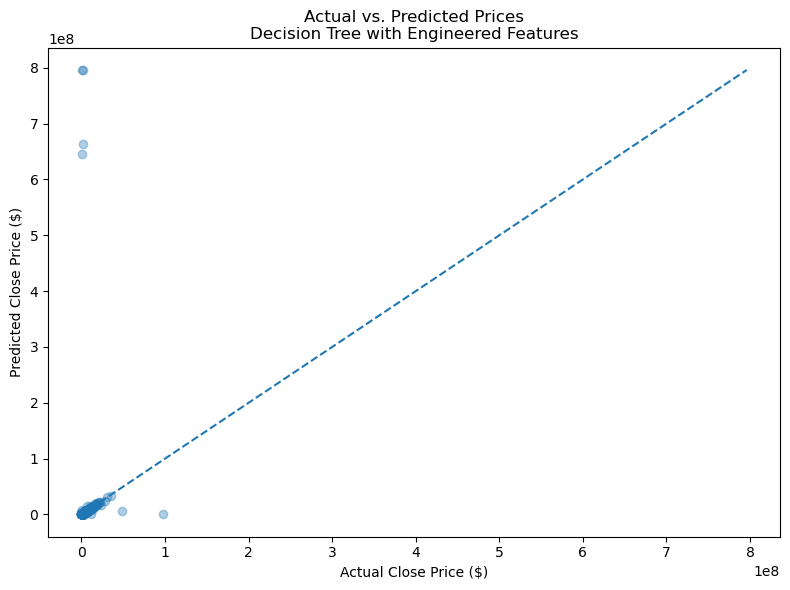

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    engineered_predictions,
    alpha=0.35,
)

minimum_price = min(
    y_test.min(),
    engineered_predictions.min(),
)

maximum_price = max(
    y_test.max(),
    engineered_predictions.max(),
)

plt.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    linestyle="--",
)

plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title(
    f"Actual vs. Predicted Prices\n"
    f"{best_model_name} with Engineered Features"
)

plt.tight_layout()
plt.show()

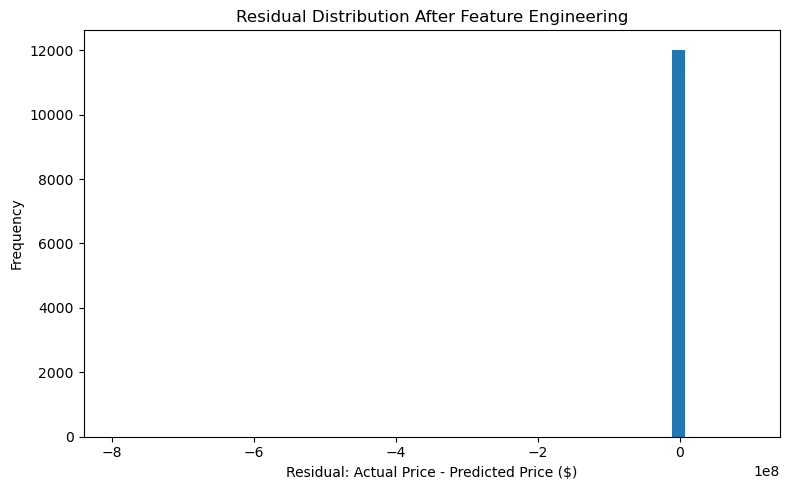

In [22]:
engineered_residuals = (
    y_test.to_numpy()
    - engineered_predictions
)

plt.figure(figsize=(8, 5))

plt.hist(
    engineered_residuals,
    bins=50,
)

plt.xlabel("Residual: Actual Price - Predicted Price ($)")
plt.ylabel("Frequency")
plt.title(
    "Residual Distribution After Feature Engineering"
)

plt.tight_layout()
plt.show()

In [23]:
if hasattr(
    engineered_model,
    "feature_importances_",
):
    feature_importance = pd.DataFrame(
        {
            "Feature": X_train_engineered.columns,
            "Importance": engineered_model.feature_importances_,
        }
    )

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False,
    ).reset_index(drop=True)

    display(
        feature_importance.head(20)
    )

elif hasattr(
    engineered_model,
    "coef_",
):
    feature_importance = pd.DataFrame(
        {
            "Feature": X_train_engineered.columns,
            "Coefficient": engineered_model.coef_,
        }
    )

    feature_importance["AbsoluteCoefficient"] = (
        feature_importance["Coefficient"].abs()
    )

    feature_importance = feature_importance.sort_values(
        by="AbsoluteCoefficient",
        ascending=False,
    ).reset_index(drop=True)

    display(
        feature_importance[
            ["Feature", "Coefficient"]
        ].head(20)
    )

else:
    feature_importance = None

    print(
        "The selected model does not provide built-in "
        "feature importance values."
    )

,Feature,Importance
0,LivingAreaPerBathroom,0.2747
1,LotToLivingAreaRatio,0.1365
2,LivingArea,0.1205
3,OutdoorSpaceApprox,0.1153
4,LogLivingArea,0.0970
5,BedBathRatio,0.0940
6,LivingAreaPerBedroom,0.0584
7,PropertyAge,0.0341
8,City_Victorville,0.0329
9,LogListPrice,0.0213


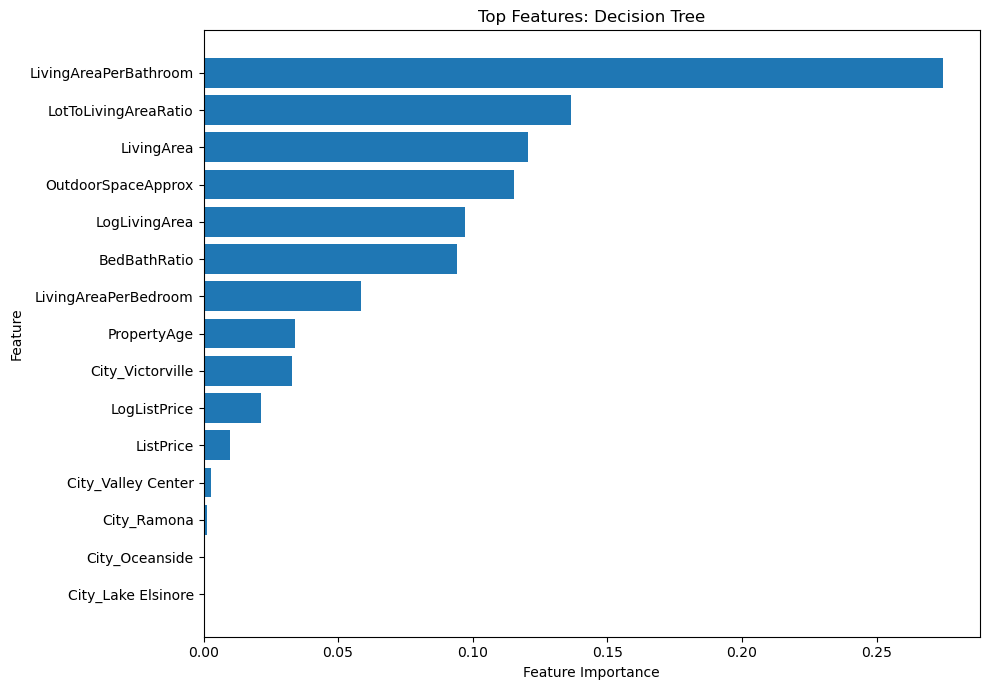

In [24]:
if feature_importance is not None:

    top_features = feature_importance.head(15).copy()

    if "Importance" in top_features.columns:
        value_column = "Importance"
        x_label = "Feature Importance"

    else:
        value_column = "AbsoluteCoefficient"
        x_label = "Absolute Coefficient"

    top_features = top_features.sort_values(
        by=value_column,
        ascending=True,
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        top_features["Feature"],
        top_features[value_column],
    )

    plt.xlabel(x_label)
    plt.ylabel("Feature")
    plt.title(
        f"Top Features: {best_model_name}"
    )

    plt.tight_layout()
    plt.show()

In [25]:
feature_metrics_file = (
    REPORTS_DIR / "feature_engineering_metrics.csv"
)

feature_comparison_file = (
    REPORTS_DIR / "feature_comparison.csv"
)

feature_comparison.to_csv(
    feature_metrics_file,
    index=False,
)

improvement_summary.to_csv(
    feature_comparison_file,
    index=False,
)

print(f"Saved: {feature_metrics_file}")
print(f"Saved: {feature_comparison_file}")

Saved: C:\Users\sonng\California_Housing_Data\reports\feature_engineering_metrics.csv
Saved: C:\Users\sonng\California_Housing_Data\reports\feature_comparison.csv


In [26]:
safe_model_name = (
    best_model_name.lower()
    .replace(" ", "_")
    .replace("-", "_")
)

engineered_model_file = (
    MODELS_DIR
    / f"{safe_model_name}_engineered_features.pkl"
)

joblib.dump(
    engineered_model,
    engineered_model_file,
)

print(f"Saved model: {engineered_model_file}")

Saved model: C:\Users\sonng\California_Housing_Data\models\decision_tree_engineered_features.pkl


In [27]:
prediction_results = pd.DataFrame(
    {
        "ActualClosePrice": y_test.reset_index(drop=True),
        "OriginalFeaturePrediction": original_predictions,
        "EngineeredFeaturePrediction": engineered_predictions,
    }
)

prediction_results["OriginalAbsoluteError"] = np.abs(
    prediction_results["ActualClosePrice"]
    - prediction_results["OriginalFeaturePrediction"]
)

prediction_results["EngineeredAbsoluteError"] = np.abs(
    prediction_results["ActualClosePrice"]
    - prediction_results["EngineeredFeaturePrediction"]
)

predictions_file = (
    REPORTS_DIR / "feature_engineering_predictions.csv"
)

prediction_results.to_csv(
    predictions_file,
    index=False,
)

print(f"Saved predictions: {predictions_file}")

prediction_results.head(10)

Saved predictions: C:\Users\sonng\California_Housing_Data\reports\feature_engineering_predictions.csv


,ActualClosePrice,OriginalFeaturePrediction,EngineeredFeaturePrediction,OriginalAbsoluteError,EngineeredAbsoluteError
0,"8,712,500.0000","9,000,000.0000","7,976,500.0000","287,500.0000","736,000.0000"
1,"1,100,000.0000","1,099,000.0000","1,025,000.0000","1,000.0000","75,000.0000"
2,"1,625,000.0000","1,400,000.0000","1,725,000.0000","225,000.0000","100,000.0000"
3,"1,560,000.0000","1,530,000.0000","1,651,500.0000","30,000.0000","91,500.0000"
4,"605,000.0000","620,000.0000","610,000.0000","15,000.0000","5,000.0000"
5,"377,500.0000","395,000.0000","385,000.0000","17,500.0000","7,500.0000"
6,"400,000.0000","400,000.0000","415,000.0000",0.0000,"15,000.0000"
7,"595,000.0000","580,000.0000","575,000.0000","15,000.0000","20,000.0000"
8,"595,000.0000","595,000.0000","590,000.0000",0.0000,"5,000.0000"
9,"2,400,000.0000","2,695,000.0000","2,710,000.0000","295,000.0000","310,000.0000"


In [28]:
mae_change = (
    original_metrics["MAE"]
    - engineered_metrics["MAE"]
)

rmse_change = (
    original_metrics["RMSE"]
    - engineered_metrics["RMSE"]
)

mape_change = (
    original_metrics["MAPE"]
    - engineered_metrics["MAPE"]
)

r2_change = (
    engineered_metrics["R2"]
    - original_metrics["R2"]
)

print("Week 6 Interpretation")
print("-" * 50)

if mae_change > 0:
    print(
        f"MAE improved by ${mae_change:,.2f}."
    )
else:
    print(
        f"MAE became worse by ${abs(mae_change):,.2f}."
    )

if rmse_change > 0:
    print(
        f"RMSE improved by ${rmse_change:,.2f}."
    )
else:
    print(
        f"RMSE became worse by ${abs(rmse_change):,.2f}."
    )

if mape_change > 0:
    print(
        f"MAPE improved by {mape_change:.2f} percentage points."
    )
else:
    print(
        "MAPE became worse by "
        f"{abs(mape_change):.2f} percentage points."
    )

if r2_change > 0:
    print(
        f"R² improved by {r2_change:.4f}."
    )
else:
    print(
        f"R² decreased by {abs(r2_change):.4f}."
    )

if mae_change > 0 and r2_change > 0:
    print(
        "\nOverall conclusion: Feature engineering improved "
        "the selected model."
    )
else:
    print(
        "\nOverall conclusion: The engineered features did not "
        "consistently improve the selected model. This is still "
        "a valid result and should be documented."
    )

Week 6 Interpretation
--------------------------------------------------
MAE became worse by $238,821.41.
RMSE became worse by $12,295,368.31.
MAPE became worse by 21.35 percentage points.
R² decreased by 62.5200.

Overall conclusion: The engineered features did not consistently improve the selected model. This is still a valid result and should be documented.


# Week 6 Summary

Feature engineering was performed to give the model more meaningful
representations of property characteristics.

## Engineered features

- Living area per bedroom
- Living area per bathroom
- Bedroom-to-bathroom ratio
- Listing price per square foot
- Lot-to-living-area ratio
- Approximate total room count
- Approximate outdoor space
- Log-transformed living area
- Log-transformed lot size
- Log-transformed listing price
- New-property indicator
- Recent-property indicator
- Older-property indicator
- Squared property age

## Evaluation

The best model from Week 5 was trained twice:

1. Using the original processed features
2. Using the feature-engineered dataset

Performance was compared using:

- Mean Absolute Error
- Root Mean Squared Error
- Mean Absolute Percentage Error
- Median Absolute Percentage Error
- R²

## Next step

The strongest feature set will be used for model tuning and more
advanced regression methods in Week 7.